In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

In [12]:
(x_train, _), (x_test, _) = cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [13]:
def get_edges(images):

    edges = []

    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        edge = cv2.Canny(gray,100,200)
        edge = edge/255.0
        edge = np.expand_dims(edge,axis=-1)
        edges.append(edge)

    return np.array(edges)

x_train_edges = get_edges(x_train)
x_test_edges = get_edges(x_test)

print(x_train_edges.shape)

(50000, 32, 32, 1)


In [14]:
x_train = (x_train / 127.5) - 1
x_test = (x_test / 127.5) - 1

x_train_edges = (x_train_edges * 2) - 1
x_test_edges = (x_test_edges * 2) - 1

# FIX dtype mismatch error
x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

x_train_edges = x_train_edges.astype(np.float32)
x_test_edges = x_test_edges.astype(np.float32)

In [15]:
def downsample(filters,size):

    initializer = tf.random_normal_initializer(0.,0.02)

    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters,size,strides=2,padding='same',
                             kernel_initializer=initializer,
                             use_bias=False))
    result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())

    return result


def upsample(filters,size):

    initializer = tf.random_normal_initializer(0.,0.02)

    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters,size,strides=2,
                                      padding='same',
                                      kernel_initializer=initializer,
                                      use_bias=False))
    result.add(layers.BatchNormalization())
    result.add(layers.ReLU())

    return result


def Generator():

    inputs = layers.Input(shape=[32,32,1])

    down1 = downsample(64,4)(inputs)
    down2 = downsample(128,4)(down1)
    down3 = downsample(256,4)(down2)

    up1 = upsample(128,4)(down3)
    up1 = layers.Concatenate()([up1,down2])

    up2 = upsample(64,4)(up1)
    up2 = layers.Concatenate()([up2,down1])

    last = layers.Conv2DTranspose(3,4,strides=2,
                                  padding='same',
                                  activation='tanh')

    outputs = last(up2)

    return tf.keras.Model(inputs=inputs,outputs=outputs)

generator = Generator()

In [16]:
def Discriminator():

    inp = layers.Input(shape=[32,32,1])
    tar = layers.Input(shape=[32,32,3])

    x = layers.concatenate([inp,tar])

    down1 = layers.Conv2D(64,4,strides=2,padding='same')(x)
    down1 = layers.LeakyReLU()(down1)

    down2 = layers.Conv2D(128,4,strides=2,padding='same')(down1)
    down2 = layers.BatchNormalization()(down2)
    down2 = layers.LeakyReLU()(down2)

    last = layers.Conv2D(1,4,strides=1,padding='same')(down2)

    return tf.keras.Model(inputs=[inp,tar],outputs=last)

discriminator = Discriminator()

In [17]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

LAMBDA = 100


def generator_loss(disc_generated_output,gen_output,target):

    gan_loss = loss_object(tf.ones_like(disc_generated_output),
                           disc_generated_output)

    l1_loss = tf.reduce_mean(tf.abs(target-gen_output))

    total_gen_loss = gan_loss + (LAMBDA*l1_loss)

    return total_gen_loss


def discriminator_loss(disc_real_output,disc_generated_output):

    real_loss = loss_object(tf.ones_like(disc_real_output),
                            disc_real_output)

    generated_loss = loss_object(tf.zeros_like(disc_generated_output),
                                 disc_generated_output)

    total_disc_loss = real_loss + generated_loss

    return total_disc_loss

In [18]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4,beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4,beta_1=0.5)

In [19]:
@tf.function
def train_step(input_image,target):

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        gen_output = generator(input_image,training=True)

        disc_real_output = discriminator([input_image,target],training=True)

        disc_generated_output = discriminator([input_image,gen_output],
                                              training=True)

        gen_loss = generator_loss(disc_generated_output,gen_output,target)

        disc_loss = discriminator_loss(disc_real_output,
                                       disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_loss,
                                            generator.trainable_variables)

    discriminator_gradients = disc_tape.gradient(disc_loss,
                                                 discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients,
                                            generator.trainable_variables))

    discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                               discriminator.trainable_variables))

In [20]:
EPOCHS = 5

for epoch in range(EPOCHS):

    for i in range(1000):

        inp = x_train_edges[i:i+1]
        tar = x_train[i:i+1]

        train_step(inp,tar)

    print("Epoch",epoch+1,"completed")

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


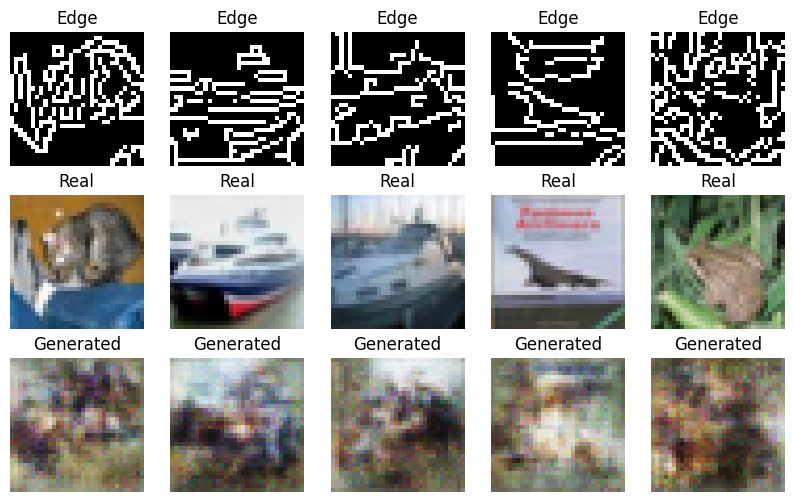

In [21]:
pred = generator(x_test_edges[:5],training=False)

plt.figure(figsize=(10,6))

for i in range(5):

    plt.subplot(3,5,i+1)
    plt.imshow(x_test_edges[i].squeeze(),cmap='gray')
    plt.title("Edge")
    plt.axis("off")

    plt.subplot(3,5,i+6)
    plt.imshow((x_test[i]+1)/2)
    plt.title("Real")
    plt.axis("off")

    plt.subplot(3,5,i+11)
    plt.imshow((pred[i]+1)/2)
    plt.title("Generated")
    plt.axis("off")

plt.show()